# Democracy's Missing Voters - Data Audit Notebook

This notebook uses the validated processed datasets in the article package, rebuilds publication tables from raw counts, regenerates the figures, and documents the provenance and limitations of the published analysis.

## 1. Scope and questions

Questions answered here:

- What do the final official Portugal 2025 participation totals show?
- How different is overseas participation from participation in the territory?
- What does the OECD 2024 trust and political voice gap suggest?
- What limitations still apply to the historical turnout context series?

The notebook is intentionally sober. It treats official, contextual, and derived values differently, and it adds diagnostic tables so the analysis goes beyond headline percentages.

In [1]:
from __future__ import annotations

from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from democracy_turnout_extract.models import ElectionTotals
from democracy_turnout_extract.validators import validate_final_cne_2025_totals
from democracy_turnout_notebook import (
    build_source_provenance_table,
    build_validation_report,
    export_current_figure,
    validate_count_identity,
    validate_percentage_identity,
)

REPO_ROOT = Path.cwd()
DATA_DIR = REPO_ROOT / 'data'
PROCESSED_DIR = DATA_DIR / 'processed'
FIGURES_DIR = REPO_ROOT / 'figures'
EXPECTED_DIRS = [DATA_DIR, FIGURES_DIR, REPO_ROOT / 'notebooks']
PROCESSED_CSVS = {
    'official_totals': PROCESSED_DIR / 'portugal_2025_final_totals.csv',
    'official_geography': PROCESSED_DIR / 'portugal_2025_participation_breakdown.csv',
    'official_trust': PROCESSED_DIR / 'oecd_2024_trust_indicators.csv',
    'historical_turnout': PROCESSED_DIR / 'portugal_legislative_turnout_1975_2025_corrected.csv',
}
for required_dir in EXPECTED_DIRS:
    assert required_dir.exists(), f'Missing required directory: {required_dir}'
for required_file in PROCESSED_CSVS.values():
    assert required_file.exists(), f'Missing required CSV: {required_file}'

pd.set_option('display.max_colwidth', 120)
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 15,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})


## 2. Load repository data

The notebook loads only validated processed outputs. That keeps the analysis aligned with the final official CNE 2025 totals and avoids reintroducing superseded intermediate article datasets.

In [2]:
historical_turnout = pd.read_csv(PROCESSED_CSVS['historical_turnout'])
official_totals = pd.read_csv(PROCESSED_CSVS['official_totals'])
official_geography = pd.read_csv(PROCESSED_CSVS['official_geography'])
official_trust = pd.read_csv(PROCESSED_CSVS['official_trust'])

display(Markdown('### Final official 2025 outputs'))
display(official_totals)
display(official_geography)


### Final official 2025 outputs

,source_name,source_url,source_status,election_name,election_date,publication_date,registered_voters,voters,abstentions,turnout_percent,abstention_percent
0,Comissao Nacional de Eleicoes,https://files.diariodarepublica.pt/1s/2025/05/104a00/0000200016.pdf,final_official,Portugal legislative election 2025,2025-05-18,2025-05-31,10848816,6319969,4528847,58.25,41.75


,geography,registered_voters,voters,abstentions,turnout_percent,abstention_percent
0,Total,10848816,6319969,4528847,58.25,41.75
1,Territory,9264094,5964951,3299143,64.39,35.61
2,Overseas,1584722,355018,1229704,22.40,77.60


## 3. Rebuild computed datasets from raw counts

For 2025, raw counts are treated as the source of truth. The notebook recomputes turnout and abstention percentages from counts, then compares those values with the stored processed percentages.

In [3]:
official_total_row = official_totals.iloc[0].copy()
official_total_row['computed_turnout_percent'] = round(
    official_total_row['voters'] / official_total_row['registered_voters'] * 100, 2
)
official_total_row['computed_abstention_percent'] = round(
    official_total_row['abstentions'] / official_total_row['registered_voters'] * 100, 2
)
official_total_row['reported_turnout_percent'] = official_total_row['turnout_percent']
official_total_row['reported_abstention_percent'] = official_total_row['abstention_percent']
official_total_row['difference_turnout_pp'] = round(
    official_total_row['reported_turnout_percent'] - official_total_row['computed_turnout_percent'], 2
)
official_total_row['difference_abstention_pp'] = round(
    official_total_row['reported_abstention_percent'] - official_total_row['computed_abstention_percent'], 2
)
official_comparison = pd.DataFrame([official_total_row])[
    [
        'registered_voters',
        'voters',
        'abstentions',
        'reported_turnout_percent',
        'computed_turnout_percent',
        'reported_abstention_percent',
        'computed_abstention_percent',
        'difference_turnout_pp',
        'difference_abstention_pp',
    ]
]

official_breakdown = official_geography.copy()
official_breakdown['reported_turnout_percent'] = official_breakdown['turnout_percent']
official_breakdown['reported_abstention_percent'] = official_breakdown['abstention_percent']
official_breakdown['computed_turnout_percent'] = (
    official_breakdown['voters'] / official_breakdown['registered_voters'] * 100
).round(2)
official_breakdown['computed_abstention_percent'] = (
    official_breakdown['abstentions'] / official_breakdown['registered_voters'] * 100
).round(2)
official_breakdown['difference_turnout_pp'] = (
    official_breakdown['reported_turnout_percent'] - official_breakdown['computed_turnout_percent']
).round(2)
official_breakdown['difference_abstention_pp'] = (
    official_breakdown['reported_abstention_percent'] - official_breakdown['computed_abstention_percent']
).round(2)

national_participation_table = official_totals[
    ['registered_voters', 'voters', 'abstentions', 'turnout_percent', 'abstention_percent']
].copy()
geography_table = official_geography[
    ['geography', 'registered_voters', 'voters', 'abstentions', 'turnout_percent', 'abstention_percent']
].copy()
trust_gap_table = official_trust.rename(columns={'value_percent': 'percent'})[
    ['indicator_name', 'population', 'percent']
].copy()
trust_gap_table['indicator_name'] = trust_gap_table['indicator_name'].replace({
    'trust_national_government': 'Trust national government',
    'low_or_no_trust_national_government': 'Low or no trust national government',
    'trust_if_feel_have_say': 'Trust if feel have a say',
    'trust_if_feel_no_say': 'Trust if feel no say',
})

display(official_comparison)
display(official_breakdown)
display(Markdown('### Historical turnout context series'))
display(historical_turnout.tail())


,registered_voters,voters,abstentions,reported_turnout_percent,computed_turnout_percent,reported_abstention_percent,computed_abstention_percent,difference_turnout_pp,difference_abstention_pp
0,10848816,6319969,4528847,58.25,58.25,41.75,41.75,0.0,0.0


,geography,registered_voters,voters,abstentions,turnout_percent,abstention_percent,reported_turnout_percent,reported_abstention_percent,computed_turnout_percent,computed_abstention_percent,difference_turnout_pp,difference_abstention_pp
0,Total,10848816,6319969,4528847,58.25,41.75,58.25,41.75,58.25,41.75,0.0,0.0
1,Territory,9264094,5964951,3299143,64.39,35.61,64.39,35.61,64.39,35.61,0.0,0.0
2,Overseas,1584722,355018,1229704,22.40,77.60,22.40,77.60,22.40,77.60,0.0,0.0


### Historical turnout context series

,year,turnout_percent,notes,source_note
14,2015,55.80,Assembly of the Republic,Repository series; historical values require official revalidation.
15,2019,48.60,Assembly of the Republic,Repository series; historical values require official revalidation.
16,2022,51.50,Assembly of the Republic,Repository series; historical values require official revalidation.
17,2024,59.90,Assembly of the Republic,Repository series; historical values require official revalidation.
18,2025,58.25,Assembly of the Republic,2025 updated to final official CNE turnout. Earlier years still require official revalidation.


## 4. Participation diagnostics

Headline turnout is useful, but it hides the size and shape of the participation gap. This section translates the validated counts into more interpretable diagnostics: turnout gaps, composition metrics, abstention-to-voter ratios, and simple counterfactuals.

In [4]:
official_turnout_value = float(official_total_row['reported_turnout_percent'])
official_registered_value = int(official_total_row['registered_voters'])
official_voters_value = int(official_total_row['voters'])
territory_row_local = official_geography.loc[official_geography['geography'] == 'Territory'].iloc[0]
overseas_row_local = official_geography.loc[official_geography['geography'] == 'Overseas'].iloc[0]
territory_turnout_value = float(territory_row_local['turnout_percent'])
overseas_turnout_value = float(overseas_row_local['turnout_percent'])

diagnostic_rows = []
for _, row in official_geography.iterrows():
    row_registered = int(row['registered_voters'])
    row_voters = int(row['voters'])
    row_abstentions = int(row['abstentions'])
    row_turnout = float(row['turnout_percent'])
    diagnostic_rows.append({
        'geography': row['geography'],
        'turnout_percent': row_turnout,
        'abstention_percent': float(row['abstention_percent']),
        'share_of_total_registered_percent': round(row_registered / official_registered_value * 100, 2),
        'share_of_total_voters_percent': round(row_voters / official_voters_value * 100, 2),
        'share_of_total_abstentions_percent': round(row_abstentions / int(official_total_row['abstentions']) * 100, 2),
        'abstentions_per_100_voters': round(row_abstentions / row_voters * 100, 2),
        'turnout_gap_vs_total_pp': round(row_turnout - official_turnout_value, 2),
        'turnout_gap_vs_territory_pp': round(row_turnout - territory_turnout_value, 2),
        'turnout_ratio_vs_total': round(row_turnout / official_turnout_value, 2),
        'turnout_ratio_vs_territory': round(row_turnout / territory_turnout_value, 2),
        'additional_voters_needed_to_match_total_turnout': max(round(row_registered * official_turnout_value / 100 - row_voters), 0),
        'additional_voters_needed_to_match_territory_turnout': max(round(row_registered * territory_turnout_value / 100 - row_voters), 0),
    })
participation_diagnostics = pd.DataFrame(diagnostic_rows)

participation_summary = pd.DataFrame([
    {
        'metric': 'overseas_share_of_registered_percent',
        'value': round(int(overseas_row_local['registered_voters']) / official_registered_value * 100, 2),
        'interpretation': 'Overseas voters are a meaningful share of the electorate, not a negligible edge case.',
    },
    {
        'metric': 'overseas_share_of_total_abstentions_percent',
        'value': round(int(overseas_row_local['abstentions']) / int(official_total_row['abstentions']) * 100, 2),
        'interpretation': 'The share of total abstentions coming from overseas shows how much the national total is shaped by lower-access constituencies.',
    },
    {
        'metric': 'territory_to_overseas_turnout_ratio',
        'value': round(territory_turnout_value / overseas_turnout_value, 2),
        'interpretation': 'Territory turnout is several times higher than overseas turnout in the same election.',
    },
    {
        'metric': 'overseas_abstentions_per_100_voters',
        'value': round(int(overseas_row_local['abstentions']) / int(overseas_row_local['voters']) * 100, 2),
        'interpretation': 'This ratio gives the scale of non-participation overseas relative to actual overseas participation.',
    },
])

peak_turnout_row = historical_turnout.loc[historical_turnout['turnout_percent'].idxmax()]
turnout_2024 = float(historical_turnout.loc[historical_turnout['year'] == 2024, 'turnout_percent'].iloc[0])
turnout_context_diagnostics = pd.DataFrame([
    {
        'metric': 'turnout_gap_vs_2024_pp',
        'value': round(official_turnout_value - turnout_2024, 2),
        'note': 'Difference between final official 2025 turnout and contextual 2024 turnout series.',
    },
    {
        'metric': 'turnout_gap_vs_series_peak_pp',
        'value': round(official_turnout_value - float(peak_turnout_row['turnout_percent']), 2),
        'note': f"Difference between 2025 turnout and the contextual series peak in {int(peak_turnout_row['year'])}.",
    },
    {
        'metric': 'additional_voters_needed_to_match_2024_turnout',
        'value': int(max(round(official_registered_value * turnout_2024 / 100 - official_voters_value), 0)),
        'note': 'Counterfactual based on contextual 2024 turnout. This is descriptive, not predictive.',
    },
    {
        'metric': 'additional_voters_needed_to_match_series_peak',
        'value': int(max(round(official_registered_value * float(peak_turnout_row['turnout_percent']) / 100 - official_voters_value), 0)),
        'note': 'Counterfactual based on the contextual historical peak. It illustrates scale only.',
    },
])

trust_values = {row['indicator_name']: float(row['value_percent']) for _, row in official_trust.iterrows()}
trust_gap_diagnostics = pd.DataFrame([
    {
        'metric': 'net_trust_balance_pp',
        'value': round(trust_values['trust_national_government'] - trust_values['low_or_no_trust_national_government'], 2),
        'note': 'Trust minus low-or-no-trust across the OECD average.',
    },
    {
        'metric': 'voice_trust_gap_pp',
        'value': round(trust_values['trust_if_feel_have_say'] - trust_values['trust_if_feel_no_say'], 2),
        'note': 'Absolute trust gap between respondents who feel they have a say and those who do not.',
    },
    {
        'metric': 'voice_trust_ratio',
        'value': round(trust_values['trust_if_feel_have_say'] / trust_values['trust_if_feel_no_say'], 2),
        'note': 'Relative trust ratio between high-voice and low-voice respondents.',
    },
    {
        'metric': 'voice_penalty_relative_to_oecd_trust_percent',
        'value': round((trust_values['trust_if_feel_have_say'] - trust_values['trust_if_feel_no_say']) / trust_values['trust_national_government'] * 100, 2),
        'note': 'Voice-related trust gap as a percentage of the baseline OECD trust level.',
    },
])

analysis_summary_table = pd.DataFrame([
    {
        'finding': 'Territory-overseas turnout gap',
        'value': f"{territory_turnout_value - overseas_turnout_value:.2f} percentage points",
        'why_it_matters': 'The gap is large enough to indicate structurally different participation conditions within the same election.',
    },
    {
        'finding': 'Additional overseas voters needed to match territory turnout',
        'value': f"{int(participation_diagnostics.loc[participation_diagnostics['geography'] == 'Overseas', 'additional_voters_needed_to_match_territory_turnout'].iloc[0]):,}",
        'why_it_matters': 'This gives the scale of the participation deficit without claiming any causal explanation.',
    },
    {
        'finding': '2025 turnout versus contextual 2024',
        'value': f"{official_turnout_value - turnout_2024:.2f} percentage points",
        'why_it_matters': 'The official 2025 result sits modestly below the contextual 2024 level, not dramatically above it.',
    },
    {
        'finding': 'OECD voice-related trust gap',
        'value': f"{trust_values['trust_if_feel_have_say'] - trust_values['trust_if_feel_no_say']:.0f} percentage points",
        'why_it_matters': 'The trust divide associated with perceived political voice is large enough to matter substantively, even without proving causality.',
    },
])

participation_diagnostics.to_csv(PROCESSED_DIR / 'portugal_2025_participation_diagnostics.csv', index=False)
participation_summary.to_csv(PROCESSED_DIR / 'portugal_2025_participation_summary.csv', index=False)
turnout_context_diagnostics.to_csv(PROCESSED_DIR / 'portugal_turnout_context_diagnostics.csv', index=False)
trust_gap_diagnostics.to_csv(PROCESSED_DIR / 'oecd_2024_trust_gap_diagnostics.csv', index=False)

display(Markdown('### Participation diagnostics'))
display(participation_diagnostics)
display(Markdown('### Participation summary metrics'))
display(participation_summary)
display(Markdown('### Turnout context diagnostics'))
display(turnout_context_diagnostics)
display(Markdown('### Trust gap diagnostics'))
display(trust_gap_diagnostics)

display(Markdown('### Analytical summary for article use'))
display(analysis_summary_table)

display(Markdown(
    f"The participation gap between territory and overseas voters is {territory_turnout_value - overseas_turnout_value:.2f} percentage points. "
    f"Overseas turnout would have required roughly {int(participation_diagnostics.loc[participation_diagnostics['geography'] == 'Overseas', 'additional_voters_needed_to_match_territory_turnout'].iloc[0]):,} additional voters to match the territory rate. "
    f"Overseas voters make up {float(participation_summary.loc[participation_summary['metric'] == 'overseas_share_of_registered_percent', 'value'].iloc[0]):.2f}% of registered voters but account for {float(participation_summary.loc[participation_summary['metric'] == 'overseas_share_of_total_abstentions_percent', 'value'].iloc[0]):.2f}% of all abstentions."
))


### Participation diagnostics

,geography,turnout_percent,abstention_percent,share_of_total_registered_percent,share_of_total_voters_percent,share_of_total_abstentions_percent,abstentions_per_100_voters,turnout_gap_vs_total_pp,turnout_gap_vs_territory_pp,turnout_ratio_vs_total,turnout_ratio_vs_territory,additional_voters_needed_to_match_total_turnout,additional_voters_needed_to_match_territory_turnout
0,Total,58.25,41.75,100.00,100.00,100.00,71.66,0.00,-6.14,1.00,0.90,0,665584
1,Territory,64.39,35.61,85.39,94.38,72.85,55.31,6.14,0.00,1.11,1.00,0,199
2,Overseas,22.40,77.60,14.61,5.62,27.15,346.38,-35.85,-41.99,0.38,0.35,568083,665384


### Participation summary metrics

,metric,value,interpretation
0,overseas_share_of_registered_percent,14.61,"Overseas voters are a meaningful share of the electorate, not a negligible edge case."
1,overseas_share_of_total_abstentions_percent,27.15,The share of total abstentions coming from overseas shows how much the national total is shaped by lower-access cons...
2,territory_to_overseas_turnout_ratio,2.87,Territory turnout is several times higher than overseas turnout in the same election.
3,overseas_abstentions_per_100_voters,346.38,This ratio gives the scale of non-participation overseas relative to actual overseas participation.


### Turnout context diagnostics

...

### Trust gap diagnostics

,metric,value,note
0,net_trust_balance_pp,-5.00,Trust minus low-or-no-trust across the OECD average.
1,voice_trust_gap_pp,47.00,Absolute trust gap between respondents who feel they have a say and those who do not.
2,voice_trust_ratio,3.14,Relative trust ratio between high-voice and low-voice respondents.
3,voice_penalty_relative_to_oecd_trust_percent,120.51,Voice-related trust gap as a percentage of the baseline OECD trust level.


### Analytical summary for article use

,finding,value,why_it_matters
0,Territory-overseas turnout gap,41.99 percentage points,The gap is large enough to indicate structurally different participation conditions within the same election.
1,Additional overseas voters needed to match territory turnout,"665,384",This gives the scale of the participation deficit without claiming any causal explanation.
2,2025 turnout versus contextual 2024,-1.65 percentage points,"The official 2025 result sits modestly below the contextual 2024 level, not dramatically above it."
3,OECD voice-related trust gap,47 percentage points,"The trust divide associated with perceived political voice is large enough to matter substantively, even without pro..."


The participation gap between territory and overseas voters is 41.99 percentage points. Overseas turnout would have required roughly 665,384 additional voters to match the territory rate. Overseas voters make up 14.61% of registered voters but account for 27.15% of all abstentions.

## 5. Data Validation

Strict checks apply to the final official 2025 totals, the derived geography breakdown, and the OECD 2024 indicators.

In [5]:
validation_results = []

official_registered = int(official_total_row['registered_voters'])
official_voters = int(official_total_row['voters'])
official_abstentions = int(official_total_row['abstentions'])
official_turnout = float(official_total_row['reported_turnout_percent'])
official_abstention = float(official_total_row['reported_abstention_percent'])

validation_results.append(
    validate_count_identity(
        'official_total_count_identity',
        official_registered,
        official_voters,
        official_abstentions,
    )
)
validation_results.extend(
    validate_percentage_identity(
        'official_total_percentage_identity',
        official_registered,
        official_voters,
        official_abstentions,
        official_turnout,
        official_abstention,
    )
)

territory_row = official_geography.loc[official_geography['geography'] == 'Territory'].iloc[0]
overseas_row = official_geography.loc[official_geography['geography'] == 'Overseas'].iloc[0]
validation_results.append(
    validate_count_identity(
        'official_geography_registered_identity',
        official_registered,
        int(territory_row['registered_voters']),
        int(overseas_row['registered_voters']),
    )
)
validation_results.append(
    validate_count_identity(
        'official_geography_voter_identity',
        official_voters,
        int(territory_row['voters']),
        int(overseas_row['voters']),
    )
)
validation_results.append(
    validate_count_identity(
        'official_geography_abstention_identity',
        official_abstentions,
        int(territory_row['abstentions']),
        int(overseas_row['abstentions']),
    )
)

required_indicators = {
    'trust_national_government',
    'low_or_no_trust_national_government',
    'trust_if_feel_have_say',
    'trust_if_feel_no_say',
}
observed_indicators = set(official_trust['indicator_name'])
indicator_status = 'pass' if observed_indicators == required_indicators else 'fail'
validation_results.append(
    type(validation_results[0])(
        check_name='oecd_required_indicators_present',
        status=indicator_status,
        expected=', '.join(sorted(required_indicators)),
        observed=', '.join(sorted(observed_indicators)),
        tolerance=0.0,
        message='all required OECD indicators are present'
        if indicator_status == 'pass'
        else 'missing required OECD indicators',
    )
)
for _, trust_row in official_trust.iterrows():
    percent_ok = 0 <= float(trust_row['value_percent']) <= 100
    validation_results.append(
        type(validation_results[0])(
            check_name=f"oecd_range_{trust_row['indicator_name']}",
            status='pass' if percent_ok else 'fail',
            expected='0-100',
            observed=f"{float(trust_row['value_percent']):.2f}",
            tolerance=0.0,
            message='indicator is within range' if percent_ok else 'indicator is out of range',
        )
    )

validation_report = build_validation_report(validation_results)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
validation_report.to_csv(PROCESSED_DIR / 'notebook_validation_report.csv', index=False)
display(validation_report)

strict_failures = validation_report.loc[validation_report['status'] == 'fail']
if not strict_failures.empty:
    raise ValueError('Strict notebook validation failed. Review notebook_validation_report.csv.')
official_model = ElectionTotals(
    source_name=str(official_total_row['source_name']),
    source_url=str(official_total_row['source_url']),
    source_status=str(official_total_row['source_status']),
    election_name=str(official_total_row['election_name']),
    election_date=pd.to_datetime(official_total_row['election_date']).date(),
    publication_date=pd.to_datetime(official_total_row['publication_date']).date(),
    registered_voters=int(official_total_row['registered_voters']),
    voters=int(official_total_row['voters']),
    abstentions=int(official_total_row['abstentions']),
    turnout_percent=float(official_total_row['reported_turnout_percent']),
    abstention_percent=float(official_total_row['reported_abstention_percent']),
)
validate_final_cne_2025_totals(official_model)


,check_name,status,expected,observed,tolerance,message
0,official_total_count_identity,pass,10848816,10848816,0.00,registered_voters equals voters + abstentions
1,official_total_percentage_identity_turnout,pass,58.25,58.25,0.05,turnout percent matches computed value
2,official_total_percentage_identity_abstention,pass,41.75,41.75,0.05,abstention percent matches computed value
3,official_total_percentage_identity_sum,pass,100.00,100.00,0.05,turnout and abstention sum to 100
4,official_geography_registered_identity,pass,10848816,10848816,0.00,registered_voters equals voters + abstentions
5,official_geography_voter_identity,pass,6319969,6319969,0.00,registered_voters equals voters + abstentions
6,official_geography_abstention_identity,pass,4528847,4528847,0.00,registered_voters equals voters + abstentions
7,oecd_required_indicators_present,pass,"low_or_no_trust_national_government, trust_if_feel_have_say, trust_if_feel_no_say, trust_national_government","low_or_no_trust_national_government, trust_if_feel_have_say, trust_if_feel_no_say, trust_national_government",0.00,all required OECD indicators are present
8,oecd_range_low_or_no_trust_national_government,pass,0-100,44.00,0.00,indicator is within range
9,oecd_range_trust_if_feel_have_say,pass,0-100,69.00,0.00,indicator is within range


## 6. Source Provenance

This table is the notebook's audit trail. It distinguishes final official, contextual, and derived inputs.

In [6]:
source_provenance = build_source_provenance_table(datetime.utcnow())
source_provenance.to_csv(DATA_DIR / 'source_provenance.csv', index=False)
display(source_provenance)


C:\Users\diogo\AppData\Local\Temp\ipykernel_13688\3279691292.py:1: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  source_provenance = build_source_provenance_table(datetime.utcnow())


,dataset,source_name,source_url,source_status,publication_date,accessed_at,extraction_type,notes
0,Portugal 2025 final official totals,CNE Mapa Oficial n.º 2-A/2025,https://files.diariodarepublica.pt/1s/2025/05/104a00/0000200016.pdf,final_official,2025-05-31,2026-07-04T22:41:09.587947,offline fixture extraction via democracy_turnout_extract,Final official national total and overseas source circles.
1,OECD 2024 trust indicators,OECD Survey on Drivers of Trust in Public Institutions – 2024 Results,https://www.oecd.org/en/publications/oecd-survey-on-drivers-of-trust-in-public-institutions-2024-results_9a20554b-en...,contextual,2024-07-10,2026-07-04T22:41:09.587947,saved HTML and report excerpt,Pinned to 2024 for the article package.
2,Portugal legislative turnout 1975–2025 series,Repository historical turnout CSV,data/portugal_legislative_turnout_1975_2025.csv,derived,,2026-07-04T22:41:09.587947,repository CSV with 2025 final override,Historical values require official revalidation before publication-grade reuse.
3,Contextual abstention framing,EDJNet / Divergente contextual article,https://www.europeandatajournalism.eu/cp_data_news/portugal-among-eu-countries-with-lowest-voter-turnout-for-governm...,contextual,,2026-07-04T22:41:09.587947,contextual reference only,Not used as the primary source for official totals.


## 7. Article-ready tables

These compact tables are built from the official processed counts and are safe to quote in the article package.

In [7]:
national_participation_table.to_csv(
    PROCESSED_DIR / 'table_1_portugal_2025_national_participation.csv', index=False
)
geography_table.to_csv(
    PROCESSED_DIR / 'table_2_portugal_2025_geography_breakdown.csv', index=False
)
trust_gap_table.to_csv(PROCESSED_DIR / 'table_3_oecd_trust_gap.csv', index=False)
official_comparison.to_csv(PROCESSED_DIR / 'portugal_2025_percentage_comparison.csv', index=False)
official_breakdown.to_csv(PROCESSED_DIR / 'portugal_2025_geography_percentage_comparison.csv', index=False)
display(Markdown('### Table 1 - Portugal 2025 national participation'))
display(national_participation_table)
display(Markdown('### Table 2 - Portugal 2025 geography breakdown'))
display(geography_table)
display(Markdown('### Table 3 - OECD trust gap'))
display(trust_gap_table)


### Table 1 - Portugal 2025 national participation

,registered_voters,voters,abstentions,turnout_percent,abstention_percent
0,10848816,6319969,4528847,58.25,41.75


### Table 2 - Portugal 2025 geography breakdown

,geography,registered_voters,voters,abstentions,turnout_percent,abstention_percent
0,Total,10848816,6319969,4528847,58.25,41.75
1,Territory,9264094,5964951,3299143,64.39,35.61
2,Overseas,1584722,355018,1229704,22.40,77.60


### Table 3 - OECD trust gap

,indicator_name,population,percent
0,Low or no trust national government,OECD average,44.0
1,Trust if feel have a say,People who feel they have a say in what government does,69.0
2,Trust if feel no say,People who feel they do not have a say in what government does,22.0
3,Trust national government,OECD average,39.0


## 8. Figures

Each figure uses Matplotlib only, a single chart per figure, and a source note placed inside the exported image.

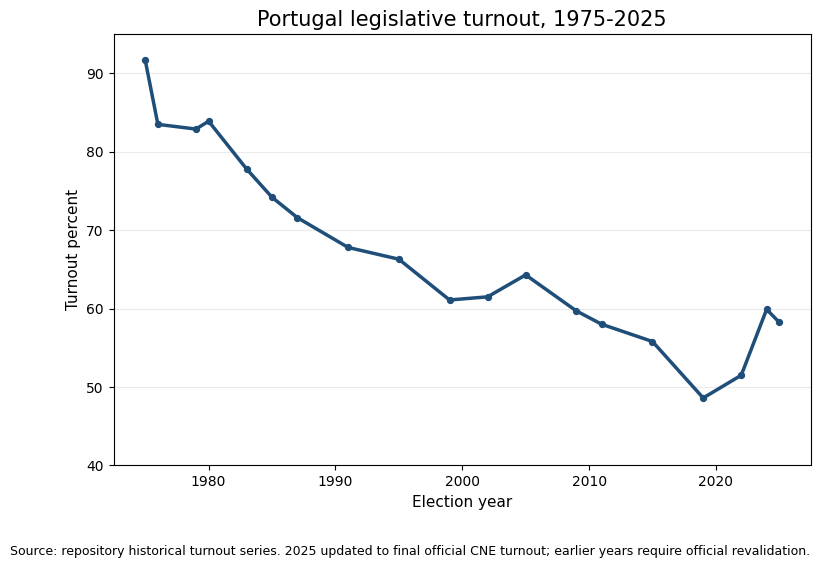

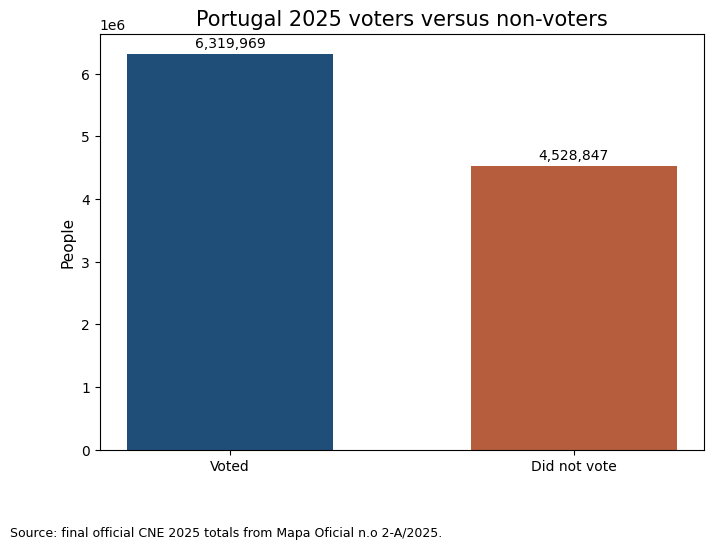

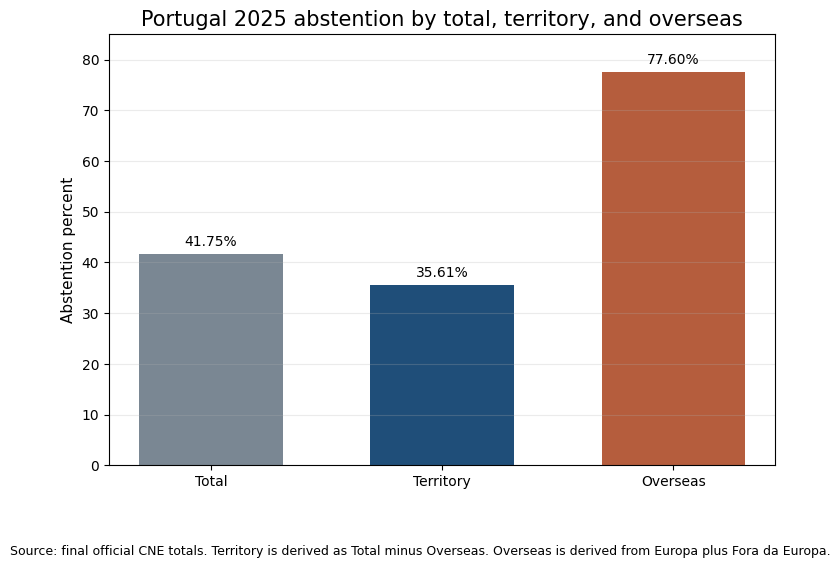

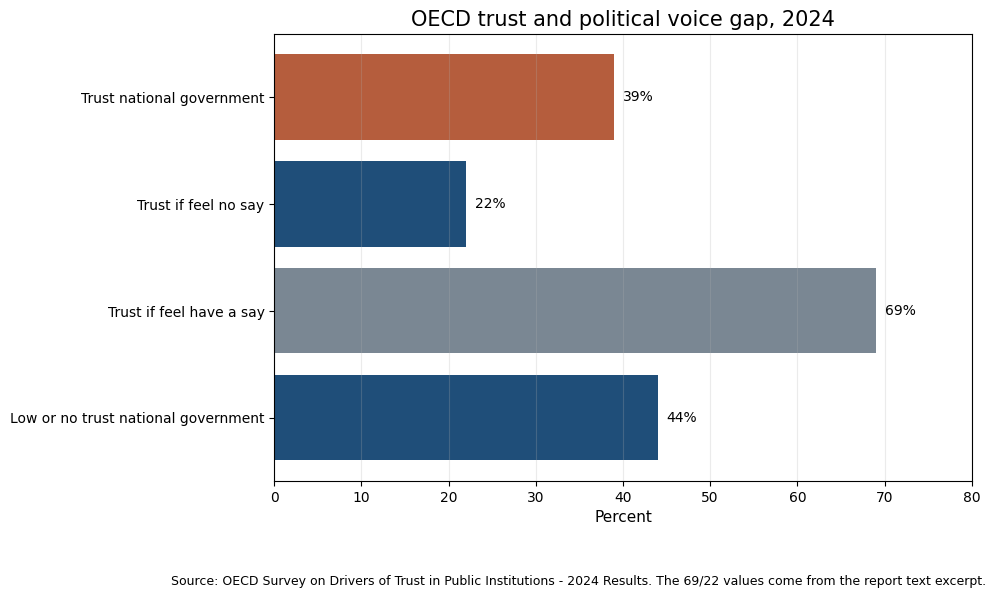

In [8]:
color_main = '#1f4e79'
color_alt = '#7a8793'
color_warn = '#b55d3d'
color_light = '#d9e2ec'

# Figure 1
fig, ax = plt.subplots(figsize=(9, 5.6))
ax.plot(historical_turnout['year'], historical_turnout['turnout_percent'], color=color_main, linewidth=2.5)
ax.scatter(historical_turnout['year'], historical_turnout['turnout_percent'], color=color_main, s=18)
ax.set_title('Portugal legislative turnout, 1975-2025')
ax.set_xlabel('Election year')
ax.set_ylabel('Turnout percent')
ax.set_ylim(40, 95)
ax.grid(axis='y', alpha=0.25)
fig.text(
    0.01,
    -0.05,
    'Source: repository historical turnout series. 2025 updated to final official CNE turnout; earlier years require official revalidation.',
    ha='left',
    fontsize=9,
)
export_current_figure(fig, FIGURES_DIR / 'figure_1_portugal_turnout_1975_2025.png')
plt.show()

# Figure 2
fig, ax = plt.subplots(figsize=(7.8, 5.4))
labels = ['Voted', 'Did not vote']
counts = [int(official_total_row['voters']), int(official_total_row['abstentions'])]
bars = ax.bar(labels, counts, color=[color_main, color_warn], width=0.6)
ax.set_title('Portugal 2025 voters versus non-voters')
ax.set_ylabel('People')
for bar, value in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 50000, f'{value:,}', ha='center', va='bottom', fontsize=10)
fig.text(
    0.01,
    -0.05,
    'Source: final official CNE 2025 totals from Mapa Oficial n.o 2-A/2025.',
    ha='left',
    fontsize=9,
)
export_current_figure(fig, FIGURES_DIR / 'figure_2_portugal_2025_voters_vs_nonvoters.png')
plt.show()

# Figure 3
fig, ax = plt.subplots(figsize=(8.6, 5.6))
bars = ax.bar(
    geography_table['geography'],
    geography_table['abstention_percent'],
    color=[color_alt, color_main, color_warn],
    width=0.62,
)
ax.set_title('Portugal 2025 abstention by total, territory, and overseas')
ax.set_ylabel('Abstention percent')
ax.set_ylim(0, 85)
ax.grid(axis='y', alpha=0.25)
for bar, value in zip(bars, geography_table['abstention_percent']):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 1.0, f'{value:.2f}%', ha='center', va='bottom', fontsize=10)
fig.text(
    0.01,
    -0.05,
    'Source: final official CNE totals. Territory is derived as Total minus Overseas. Overseas is derived from Europa plus Fora da Europa.',
    ha='left',
    fontsize=9,
)
export_current_figure(fig, FIGURES_DIR / 'figure_3_portugal_2025_abstention_geography.png')
plt.show()

# Figure 4
fig, ax = plt.subplots(figsize=(9, 5.8))
ordered = trust_gap_table.copy()
bars = ax.barh(ordered['indicator_name'], ordered['percent'], color=[color_main, color_alt, color_main, color_warn])
ax.set_title('OECD trust and political voice gap, 2024')
ax.set_xlabel('Percent')
ax.set_xlim(0, 80)
ax.grid(axis='x', alpha=0.25)
for bar, value in zip(bars, ordered['percent']):
    ax.text(value + 1.0, bar.get_y() + bar.get_height() / 2, f'{value:.0f}%', va='center', fontsize=10)
fig.text(
    0.01,
    -0.07,
    'Source: OECD Survey on Drivers of Trust in Public Institutions - 2024 Results. The 69/22 values come from the report text excerpt.',
    ha='left',
    fontsize=9,
)
export_current_figure(fig, FIGURES_DIR / 'figure_4_oecd_trust_voice_gap.png')
plt.show()


## 9. Interpretation and limitations

- Overseas participation is far below participation in the territory.
- The diagnostics section now also quantifies composition: overseas voters are a meaningful share of the electorate and an even larger share of abstentions.
- The territory-overseas turnout gap is not marginal; it is structurally large in percentage-point, ratio, and absolute-voter terms.
- The OECD trust gap is also a political voice gap: respondents who feel they have a say report much higher trust than those who do not.
- The counterfactual turnout metrics are descriptive scale checks, not forecasts and not causal estimates.
- The historical turnout line remains useful context, but earlier years should be revalidated from official primary sources before being treated as publication-grade.

## 10. Future Extension: Municipal Abstention Model

This section is scaffolding only. It does not claim that municipality-level data is already extracted.

In [9]:
def load_municipality_election_data(path: Path) -> pd.DataFrame:
    """Load municipality-level election data once an official dataset is available."""
    raise NotImplementedError('Municipality-level election extraction is future work.')

def load_municipality_indicators(path: Path) -> pd.DataFrame:
    """Load municipality-level socio-economic indicators for later joins."""
    raise NotImplementedError('Municipality-level indicator extraction is future work.')

def normalize_municipality_names(frame: pd.DataFrame) -> pd.DataFrame:
    """Normalize municipality names before any joins across sources."""
    raise NotImplementedError('Municipality name normalization is future work.')

def join_municipality_datasets(election_data: pd.DataFrame, indicators: pd.DataFrame) -> pd.DataFrame:
    """Join election and socio-economic data using stable municipality keys where possible."""
    raise NotImplementedError('Municipality joins are future work.')

display(Markdown(
    'Future work should document key choice, municipality name normalization, and the risk of ecological fallacy. Correlation would not prove individual voting behaviour.'
))


Future work should document key choice, municipality name normalization, and the risk of ecological fallacy. Correlation would not prove individual voting behaviour.

## 11. Notebook quality checks

The final cell asserts that the notebook produced the expected outputs.

In [10]:
expected_figures = [
    FIGURES_DIR / 'figure_1_portugal_turnout_1975_2025.png',
    FIGURES_DIR / 'figure_2_portugal_2025_voters_vs_nonvoters.png',
    FIGURES_DIR / 'figure_3_portugal_2025_abstention_geography.png',
    FIGURES_DIR / 'figure_4_oecd_trust_voice_gap.png',
]
expected_csv_outputs = [
    PROCESSED_DIR / 'notebook_validation_report.csv',
    DATA_DIR / 'source_provenance.csv',
    PROCESSED_DIR / 'table_1_portugal_2025_national_participation.csv',
    PROCESSED_DIR / 'table_2_portugal_2025_geography_breakdown.csv',
    PROCESSED_DIR / 'table_3_oecd_trust_gap.csv',
    PROCESSED_DIR / 'portugal_2025_participation_diagnostics.csv',
    PROCESSED_DIR / 'portugal_2025_participation_summary.csv',
    PROCESSED_DIR / 'portugal_turnout_context_diagnostics.csv',
    PROCESSED_DIR / 'oecd_2024_trust_gap_diagnostics.csv',
]
for path in expected_figures + expected_csv_outputs:
    assert path.exists(), f'Missing expected output: {path}'
assert validation_report.loc[validation_report['status'] == 'fail'].empty, 'Validation report contains strict failures.'
assert not source_provenance.empty, 'Source provenance table is missing.'
assert int(official_total_row['registered_voters']) == 10_848_816
assert int(official_total_row['voters']) == 6_319_969
assert int(official_total_row['abstentions']) == 4_528_847
assert float(official_total_row['reported_turnout_percent']) == 58.25
assert float(official_total_row['reported_abstention_percent']) == 41.75
print('Notebook quality checks passed. Figures, tables, provenance, and strict validations are in place.')


Notebook quality checks passed. Figures, tables, provenance, and strict validations are in place.
